In [1]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================

# NOTE: We deliberately do NOT touch torch / torchvision / torchaudio.
# Colab ships a pre-matched build of that trio for its GPU runtime's
# CUDA version. Reinstalling any one of them from generic PyPI wheels
# breaks that match (symptoms: "operator torchvision::nms does not
# exist", torchaudio/torch CUDA-version RuntimeErrors, or a confusing
# "Could not import module 'Gemma2Model'" ModuleNotFoundError while
# loading the model later). Only upgrade the pure-Python packages.
!pip uninstall -y transformers
!pip install -U datasets pandas matplotlib seaborn transformers accelerate numpy


Found existing installation: transformers 5.15.0
Uninstalling transformers-5.15.0:
  Successfully uninstalled transformers-5.15.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 7.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Un

In [1]:
# ============================================================
# CELL 2 — IMPORTS AND CONFIGURATION
# ============================================================

import os
import gc
import json
import random
import zipfile
import joblib

import numpy as np
import pandas as pd

import torch

from tqdm.auto import tqdm

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModel
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MODEL_NAME = "google/gemma-2-2b"

LAYER = 14

MAX_LENGTH = 64

BATCH_SIZE = 16

TOXICITY_THRESHOLD = 0.5

# ------------------------------------------------------------
# Experiment size
# ------------------------------------------------------------

# Start small for testing.
#
# Set to None later if you want to process the complete
# Civil Comments training set.

TRAIN_SIZE = 15_000
VAL_SIZE = 5_000

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

OUTPUT_DIR = "toxicity_probe"

EMBEDDING_DIR = os.path.join(
    OUTPUT_DIR,
    "embeddings"
)

SUBMISSION_DIR = os.path.join(
    OUTPUT_DIR,
    "submission"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(EMBEDDING_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# ============================================================
# CELL 3 — HUGGING FACE LOGIN
# ============================================================

from huggingface_hub import login

# Uncomment and run this cell if authentication is required.
#
# login()

In [4]:
# ============================================================
# CELL 4 — LOAD CIVIL COMMENTS DATASET
# ============================================================

dataset = load_dataset(
    "google/civil_comments"
)

print(dataset)

README.md:   0%|          | 0.00/7.73k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  194MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  187MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1804874 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/97320 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/97320 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 1804874
    })
    validation: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 97320
    })
    test: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 97320
    })
})


In [5]:
# ============================================================
# CELL 5 — INSPECT DATASET
# ============================================================

print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))
print("Test size:", len(dataset["test"]))

print("\nColumns:")
print(dataset["train"].column_names)

print("\nExample:")
print(dataset["train"][0])

Train size: 1804874
Validation size: 97320
Test size: 97320

Columns:
['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit']

Example:
{'text': "This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!", 'toxicity': 0.0, 'severe_toxicity': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_attack': 0.0, 'sexual_explicit': 0.0}


In [6]:
# ============================================================
# CELL 6 — EXPLORE TOXICITY DISTRIBUTION
# ============================================================

train_df_sample = dataset["train"].select(
    range(min(100_000, len(dataset["train"])))
).to_pandas()

print(
    train_df_sample["toxicity"].describe()
)

count    100000.000000
mean          0.090475
std           0.187118
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: toxicity, dtype: float64


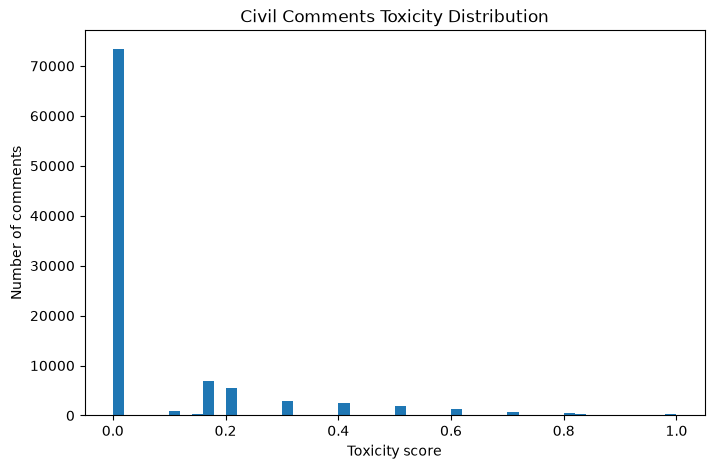

In [7]:
# ============================================================
# TOXICITY DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    train_df_sample["toxicity"],
    bins=50
)

plt.xlabel("Toxicity score")
plt.ylabel("Number of comments")
plt.title("Civil Comments Toxicity Distribution")

plt.show()

In [8]:
# ============================================================
# CELL 7 — CREATE BINARY LABEL
# ============================================================

def create_binary_label(example):
    """
    Convert Civil Comments toxicity score into
    a binary classification label.

    Parameters
    ----------
    example : dict
        Dataset example containing `toxicity`.

    Returns
    -------
    dict
        Example with additional `label` field.
    """

    example["label"] = int(
        example["toxicity"] >= TOXICITY_THRESHOLD
    )

    return example

In [9]:
# ============================================================
# CELL 8 — CREATE TRAIN / VALIDATION DATA
# ============================================================

train_dataset = dataset["train"].shuffle(
    seed=SEED
)

validation_dataset = dataset["validation"].shuffle(
    seed=SEED
)

# ------------------------------------------------------------
# Select subsets for initial experimentation
# ------------------------------------------------------------

if TRAIN_SIZE is not None:

    train_dataset = train_dataset.select(
        range(
            min(
                TRAIN_SIZE,
                len(train_dataset)
            )
        )
    )

if VAL_SIZE is not None:

    validation_dataset = validation_dataset.select(
        range(
            min(
                VAL_SIZE,
                len(validation_dataset)
            )
        )
    )

# ------------------------------------------------------------
# Create labels
# ------------------------------------------------------------

train_dataset = train_dataset.map(
    create_binary_label
)

validation_dataset = validation_dataset.map(
    create_binary_label
)

print(
    "Training examples:",
    len(train_dataset)
)

print(
    "Validation examples:",
    len(validation_dataset)
)

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Training examples: 15000
Validation examples: 5000


In [10]:
# ============================================================
# CELL 9 — CHECK CLASS BALANCE
# ============================================================

from collections import Counter

train_counts = Counter(
    train_dataset["label"]
)

val_counts = Counter(
    validation_dataset["label"]
)

print("Training class distribution:")
print(train_counts)

print("\nValidation class distribution:")
print(val_counts)

print("\nTraining proportions:")

total = sum(train_counts.values())

for label, count in sorted(train_counts.items()):

    print(
        f"Class {label}: "
        f"{count / total:.2%}"
    )

Training class distribution:
Counter({0: 13808, 1: 1192})

Validation class distribution:
Counter({0: 4604, 1: 396})

Training proportions:
Class 0: 92.05%
Class 1: 7.95%


In [11]:
# ============================================================
# CELL 10 — LOAD GEMMA-2-2B
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    device_map="auto",
    output_hidden_states=True
)

model.eval()

print("Model loaded.")

print(
    "Number of hidden layers:",
    model.config.num_hidden_layers
)

print(
    "Hidden size:",
    model.config.hidden_size
)

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Model loaded.
Number of hidden layers: 26
Hidden size: 2304


In [12]:
# ============================================================
# CELL 11 — VERIFY MODEL DEVICE
# ============================================================

print(
    "Model device:",
    model.device
)

if torch.cuda.is_available():

    print(
        "GPU memory allocated:",
        round(
            torch.cuda.memory_allocated() / 1024**3,
            2
        ),
        "GB"
    )

    print(
        "GPU memory reserved:",
        round(
            torch.cuda.memory_reserved() / 1024**3,
            2
        ),
        "GB"
    )

Model device: cuda:0
GPU memory allocated: 4.87 GB
GPU memory reserved: 4.87 GB


In [13]:
# ============================================================
# CELL 12 — MEAN POOLING
# ============================================================

def mean_pool(
    hidden_states,
    attention_mask
):
    """
    Mean-pool token embeddings while ignoring padding tokens.

    Parameters
    ----------
    hidden_states : torch.Tensor
        Shape:
        (batch_size, sequence_length, hidden_size)

    attention_mask : torch.Tensor
        Shape:
        (batch_size, sequence_length)

    Returns
    -------
    torch.Tensor
        Shape:
        (batch_size, hidden_size)
    """

    mask = attention_mask.unsqueeze(-1)

    mask = mask.to(
        hidden_states.dtype
    )

    summed = (
        hidden_states * mask
    ).sum(dim=1)

    counts = mask.sum(
        dim=1
    ).clamp(min=1)

    pooled = summed / counts

    return pooled

In [14]:
# ============================================================
# CELL 13 — TEST TOKENIZATION
# ============================================================

example_texts = [
    "This is a perfectly normal comment.",
    "I completely disagree with your argument."
]

inputs = tokenizer(
    example_texts,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

print("Input IDs shape:")
print(inputs["input_ids"].shape)

print("\nAttention mask:")
print(inputs["attention_mask"])

Input IDs shape:
torch.Size([2, 8])

Attention mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1]])


In [15]:
# ============================================================
# CELL 14 — EXTRACT GEMMA LAYER-14 EMBEDDINGS
# ============================================================

@torch.no_grad()
def extract_embeddings(
    data,
    batch_size=BATCH_SIZE
):
    """
    Extract Gemma layer-14 mean-pooled embeddings.

    Parameters
    ----------
    data : Hugging Face Dataset
        Dataset containing `text` and `label`.

    batch_size : int
        Number of texts processed at once.

    Returns
    -------
    X : np.ndarray
        Embeddings.

    y : np.ndarray
        Binary labels.
    """

    all_embeddings = []
    all_labels = []

    for start in tqdm(
        range(
            0,
            len(data),
            batch_size
        ),
        desc="Extracting embeddings"
    ):

        end = min(
            start + batch_size,
            len(data)
        )

        batch = data[
            start:end
        ]

        texts = batch["text"]

        labels = batch["label"]

        # ----------------------------------------------------
        # Tokenization
        # ----------------------------------------------------

        inputs = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        inputs = {
            key: value.to(model.device)
            for key, value in inputs.items()
        }

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(
            **inputs
        )

        # ----------------------------------------------------
        # Extract layer 14
        # ----------------------------------------------------

        layer_embeddings = (
            outputs.hidden_states[LAYER]
        )

        # ----------------------------------------------------
        # Mean pool valid tokens
        # ----------------------------------------------------

        pooled = mean_pool(
            layer_embeddings,
            inputs["attention_mask"]
        )

        # ----------------------------------------------------
        # Move to CPU
        # ----------------------------------------------------

        pooled = (
            pooled
            .float()
            .cpu()
            .numpy()
        )

        all_embeddings.append(
            pooled
        )

        all_labels.extend(
            labels
        )

    X = np.concatenate(
        all_embeddings,
        axis=0
    )

    y = np.asarray(
        all_labels,
        dtype=np.int64
    )

    return X, y

In [17]:
# ============================================================
# CELL 15 — EXTRACT TRAINING EMBEDDINGS
# ============================================================

X_train, y_train = extract_embeddings(
    train_dataset
)

print(
    "X_train shape:",
    X_train.shape
)

print(
    "y_train shape:",
    y_train.shape
)

print(
    "X_train dtype:",
    X_train.dtype
)

Extracting embeddings:   0%|          | 0/938 [00:00<?, ?it/s]

X_train shape: (15000, 2304)
y_train shape: (15000,)
X_train dtype: float32


In [16]:
# ============================================================
# CELL 16 — MEMORY CLEANUP
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleanup completed.")

Memory cleanup completed.


In [18]:
# ============================================================
# CELL 17 — EXTRACT VALIDATION EMBEDDINGS
# ============================================================

X_val, y_val = extract_embeddings(
    validation_dataset
)

print(
    "X_val shape:",
    X_val.shape
)

print(
    "y_val shape:",
    y_val.shape
)

Extracting embeddings:   0%|          | 0/313 [00:00<?, ?it/s]

X_val shape: (5000, 2304)
y_val shape: (5000,)


In [19]:
# ============================================================
# CELL 18 — SAVE EMBEDDINGS
# ============================================================

X_train_path = os.path.join(
    EMBEDDING_DIR,
    "X_train_layer14.npy"
)

y_train_path = os.path.join(
    EMBEDDING_DIR,
    "y_train.npy"
)

X_val_path = os.path.join(
    EMBEDDING_DIR,
    "X_val_layer14.npy"
)

y_val_path = os.path.join(
    EMBEDDING_DIR,
    "y_val.npy"
)

np.save(
    X_train_path,
    X_train
)

np.save(
    y_train_path,
    y_train
)

np.save(
    X_val_path,
    X_val
)

np.save(
    y_val_path,
    y_val
)

print("Embeddings saved.")

Embeddings saved.


In [20]:
# ============================================================
# CELL 19 — VERIFY SAVED EMBEDDINGS
# ============================================================

X_train_loaded = np.load(
    X_train_path
)

y_train_loaded = np.load(
    y_train_path
)

X_val_loaded = np.load(
    X_val_path
)

y_val_loaded = np.load(
    y_val_path
)

print(
    "Train:",
    X_train_loaded.shape,
    y_train_loaded.shape
)

print(
    "Validation:",
    X_val_loaded.shape,
    y_val_loaded.shape
)

Train: (15000, 2304) (15000,)
Validation: (5000, 2304) (5000,)


In [21]:
# ============================================================
# CELL 20 — TRAIN LOGISTIC REGRESSION LINEAR PROBE
# ============================================================

logistic_probe = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        LogisticRegression(
            C=1.0,
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=SEED
        )
    )
])

logistic_probe.fit(
    X_train,
    y_train
)

print("Logistic regression trained.")

Logistic regression trained.


In [22]:
# ============================================================
# CELL 21 — EVALUATE LOGISTIC REGRESSION
# ============================================================

logistic_predictions = (
    logistic_probe.predict(
        X_val
    )
)

logistic_accuracy = accuracy_score(
    y_val,
    logistic_predictions
)

print(
    f"Validation accuracy: "
    f"{logistic_accuracy:.4f}"
)

print("\nClassification report:")

print(
    classification_report(
        y_val,
        logistic_predictions
    )
)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_val,
        logistic_predictions
    )
)

Validation accuracy: 0.8676

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      4604
           1       0.28      0.43      0.34       396

    accuracy                           0.87      5000
   macro avg       0.62      0.67      0.63      5000
weighted avg       0.90      0.87      0.88      5000


Confusion matrix:
[[4167  437]
 [ 225  171]]


In [23]:
# ============================================================
# CELL 22 — HYPERPARAMETER SEARCH: LOGISTIC REGRESSION
# ============================================================

C_VALUES = [
    0.001,
    10.0
]

results = []

for C in C_VALUES:

    probe = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),

        (
            "classifier",
            LogisticRegression(
                C=C,
                max_iter=2000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=SEED
            )
        )
    ])

    probe.fit(
        X_train,
        y_train
    )

    predictions = probe.predict(
        X_val
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    results.append({
        "model": "LogisticRegression",
        "C": C,
        "accuracy": accuracy
    })

    print(
        f"C={C:<8} "
        f"accuracy={accuracy:.4f}"
    )

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "accuracy",
    ascending=False
)

print("\nResults:")
display(results_df)

C=0.001    accuracy=0.8456
C=10.0     accuracy=0.8696

Results:


,model,C,accuracy
1,LogisticRegression,10.000,0.8696
0,LogisticRegression,0.001,0.8456


In [24]:
# ============================================================
# CELL 23 — COMPARE CLASS WEIGHTS
# ============================================================

class_weight_results = []

for class_weight in [
    None,
    "balanced"
]:

    probe = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),

        (
            "classifier",
            LogisticRegression(
                C=1.0,
                max_iter=2000,
                class_weight=class_weight,
                solver="lbfgs",
                random_state=SEED
            )
        )
    ])

    probe.fit(
        X_train,
        y_train
    )

    predictions = probe.predict(
        X_val
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    class_weight_results.append({
        "class_weight": str(class_weight),
        "accuracy": accuracy
    })

class_weight_df = pd.DataFrame(
    class_weight_results
)

display(
    class_weight_df
)

,class_weight,accuracy
0,None,0.8844
1,balanced,0.8676


In [ ]:
# ============================================================
# CELL 24 — (REMOVED) LINEAR SVM
# ============================================================

# SVM comparison removed — this project uses Logistic Regression only.


In [ ]:
# ============================================================
# CELL 25 — SELECT BEST MODEL
# ============================================================

# Only Logistic Regression results are considered (SVM removed).
all_results = results_df.sort_values(
    "accuracy",
    ascending=False
)

display(all_results)


In [27]:
# ============================================================
# BEST MODEL CONFIGURATION
# ============================================================

best_row = all_results.iloc[0]

print(
    "Best model:"
)

print(
    best_row
)

Best model:
model       LinearSVC
C                 1.0
accuracy       0.8708
Name: 3, dtype: object


In [ ]:
# ============================================================
# CELL 26 — TRAIN FINAL PROBE
# ============================================================

best_model_name = best_row["model"]
best_C = best_row["C"]

print(
    "Selected model:",
    best_model_name
)

print(
    "Selected C:",
    best_C
)

# Logistic Regression only — SVM branch removed.
final_probe = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        LogisticRegression(
            C=best_C,
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=SEED
        )
    )
])

final_probe.fit(
    X_train,
    y_train
)

print(
    "Final probe trained."
)


In [ ]:
# ============================================================
# CELL 27 — FINAL VALIDATION EVALUATION
# ============================================================

final_predictions = final_probe.predict(
    X_val
)

final_accuracy = accuracy_score(
    y_val,
    final_predictions
)

print(
    f"FINAL VALIDATION ACCURACY: "
    f"{final_accuracy:.4f}"
)

print("\nClassification report:")

print(
    classification_report(
        y_val,
        final_predictions
    )
)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_val,
        final_predictions
    )
)

In [ ]:
# ============================================================
# CELL 28 — SAVE TRAINED PROBE
# ============================================================

MODEL_PATH = os.path.join(
    SUBMISSION_DIR,
    "classifier.joblib"
)

joblib.dump(
    final_probe,
    MODEL_PATH
)

print(
    "Model saved to:",
    MODEL_PATH
)

print(
    "File size:",
    round(
        os.path.getsize(MODEL_PATH) / 1024**2,
        2
    ),
    "MB"
)

In [ ]:
# ============================================================
# CELL 29 — CREATE classifier.py
# ============================================================

classifier_code = r'''
import os
import joblib
import numpy as np


MODEL_PATH = os.path.join(
    os.path.dirname(__file__),
    "classifier.joblib"
)


# Load trained linear probe once.
MODEL = joblib.load(MODEL_PATH)


def predict(embeddings):
    """
    Predict toxicity labels from Gemma layer-14 embeddings.

    Parameters
    ----------
    embeddings : numpy.ndarray
        A matrix of Gemma layer-14 mean-pooled embeddings.

        Shape:
            (n_samples, embedding_dim)

    Returns
    -------
    numpy.ndarray
        Binary predictions.

        0 = safe
        1 = toxic
    """

    X = np.asarray(
        embeddings,
        dtype=np.float32
    )

    if X.ndim == 1:
        X = X.reshape(1, -1)

    predictions = MODEL.predict(X)

    return np.asarray(
        predictions,
        dtype=np.int64
    )
'''

CLASSIFIER_PATH = os.path.join(
    SUBMISSION_DIR,
    "classifier.py"
)

with open(
    CLASSIFIER_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        classifier_code
    )

print(
    "Created:",
    CLASSIFIER_PATH
)

In [ ]:
# ============================================================
# CELL 30 — TEST SUBMISSION CLASSIFIER
# ============================================================

import sys

sys.path.insert(
    0,
    SUBMISSION_DIR
)

from classifier import predict

test_predictions = predict(
    X_val[:100]
)

print(
    "Predictions:",
    test_predictions[:20]
)

print(
    "Shape:",
    test_predictions.shape
)

print(
    "Unique labels:",
    np.unique(test_predictions)
)

assert test_predictions.shape == (
    100,
)

assert np.all(
    np.isin(
        test_predictions,
        [0, 1]
    )
)

print(
    "\nSubmission classifier test PASSED."
)

In [ ]:
# ============================================================
# CELL 31 — VERIFY SUBMISSION DIRECTORY
# ============================================================

print(
    "Submission directory:"
)

for filename in os.listdir(
    SUBMISSION_DIR
):

    filepath = os.path.join(
        SUBMISSION_DIR,
        filename
    )

    print(
        f"  {filename:<25} "
        f"{os.path.getsize(filepath) / 1024**2:.2f} MB"
    )

In [ ]:
# ============================================================
# CELL 32 — CREATE SUBMISSION ZIP
# ============================================================

ZIP_PATH = os.path.join(
    OUTPUT_DIR,
    "submission.zip"
)

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    zip_file.write(
        CLASSIFIER_PATH,
        arcname="classifier.py"
    )

    zip_file.write(
        MODEL_PATH,
        arcname="classifier.joblib"
    )

print(
    "Submission ZIP created:"
)

print(
    ZIP_PATH
)

In [ ]:
# ============================================================
# CELL 33 — VERIFY ZIP STRUCTURE
# ============================================================

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as zip_file:

    files = zip_file.namelist()

    print(
        "Files inside ZIP:"
    )

    for file in files:
        print(
            "  ",
            file
        )

    assert "classifier.py" in files
    assert "classifier.joblib" in files

    # Ensure there are no extra directories.
    for file in files:

        assert "/" not in file

print(
    "\nZIP structure is valid."
)

In [ ]:
# ============================================================
# CELL 34 — DOWNLOAD SUBMISSION
# ============================================================

from google.colab import files

files.download(
    ZIP_PATH
)